# our next challenge is using scipi's library in python and using cubic spline interplolation

## it certainly has some limitations such as the first and the second derivatives must be continous and meet the boundary condition and interpolation condition

### we will compare a polynomial curve fitting with a cubic spline curve fitting it doesn't say analyze the error in the problem statement but I think it will be useful and will add it 


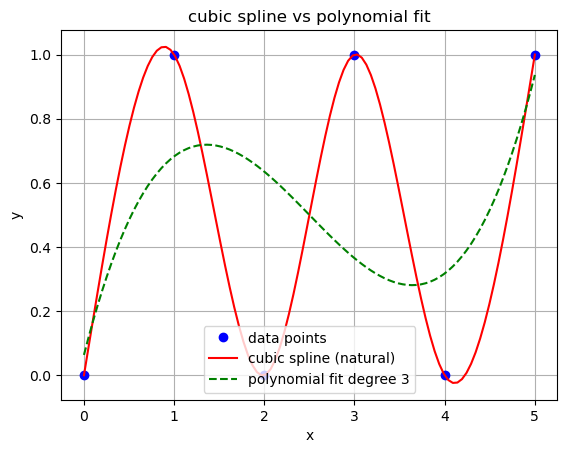

Cubic Spline:   MSE = 0.0000   R-squared = 1.0000
Polynomial fit: MSE = 0.1693   R-squared = 0.3228

Cubic spline is the better fit


In [1]:
import numpy as np
import math
import time
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])


cs = CubicSpline(x, y, bc_type="natural")

# generate new x values for smooth plot
x_interp = np.linspace(0, 5, 100)
y_interp = cs(x_interp)

# polynomial fit using polyfit degree 3
coefficients = np.polyfit(x, y, 3)
polynomial = np.poly1d(coefficients)
y_pred_poly = polynomial(x_interp)

# mse and r-squared for cubic spline
y_spline_at_x = cs(x)
ss_total = np.sum((y - np.mean(y))**2)
mse_spline = np.mean((y - y_spline_at_x)**2)
r_squared_spline = 1 - (np.sum((y - y_spline_at_x)**2) / ss_total)

# mse and r-squared for polynomial
y_poly_at_x = polynomial(x)
mse_poly = np.mean((y - y_poly_at_x)**2)
r_squared_poly = 1 - (np.sum((y - y_poly_at_x)**2) / ss_total)

# plot both on same graph
plt.figure()
plt.plot(x, y, "bo", label="data points")
plt.plot(x_interp, y_interp, color="red", label="cubic spline (natural)")
plt.plot(x_interp, y_pred_poly, color="green", linestyle="--", label=f"polynomial fit degree 3")
plt.xlabel("x")
plt.ylabel("y")
plt.title("cubic spline vs polynomial fit")
plt.legend()
plt.grid(True)
plt.show()

# 
print(f"Cubic Spline:   MSE = {mse_spline:.4f}   R-squared = {r_squared_spline:.4f}")
print(f"Polynomial fit: MSE = {mse_poly:.4f}   R-squared = {r_squared_poly:.4f}")
print()

if mse_spline < mse_poly:
    print("Cubic spline is the better fit")
else:
    print("Polynomial fit is the better fit")

it is obvious that the 3 conditions were met because we have perfect MSE and R-Squared values. I didn't think this was even possible so its very cool to see 